In [1]:
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
tri_current, tri_voltage, mit_current, mit_voltage = [], [], [], []

## TRI Dataset

In [3]:
matFilename = '../../data/raw/2018-04-12_batchdata_updated_struct_errorcorrect.mat'
f = h5py.File(matFilename)
batch = f['batch']
num_cells = batch['summary'].shape[0]
tri_bat_dict = {}
for i in range(num_cells):
    cl = f[batch['cycle_life'][i,0]][:]
    policy = f[batch['policy_readable'][i,0]][:].tobytes()[::2].decode()
    summary_IR = np.hstack(f[batch['summary'][i,0]]['IR'][0,:].tolist())
    summary_QC = np.hstack(f[batch['summary'][i,0]]['QCharge'][0,:].tolist())
    summary_QD = np.hstack(f[batch['summary'][i,0]]['QDischarge'][0,:].tolist())
    summary_TA = np.hstack(f[batch['summary'][i,0]]['Tavg'][0,:].tolist())
    summary_TM = np.hstack(f[batch['summary'][i,0]]['Tmin'][0,:].tolist())
    summary_TX = np.hstack(f[batch['summary'][i,0]]['Tmax'][0,:].tolist())
    summary_CT = np.hstack(f[batch['summary'][i,0]]['chargetime'][0,:].tolist())
    summary_CY = np.hstack(f[batch['summary'][i,0]]['cycle'][0,:].tolist())
    summary = {'IR': summary_IR, 'QC': summary_QC, 'QD': summary_QD, 'Tavg':
                summary_TA, 'Tmin': summary_TM, 'Tmax': summary_TX, 'chargetime': summary_CT,
                'cycle': summary_CY}
    cycles = f[batch['cycles'][i,0]]
    cycle_dict = {}
    for j in range(cycles['I'].shape[0]):
        I = np.hstack((f[cycles['I'][j,0]][:]))
        Qc = np.hstack((f[cycles['Qc'][j,0]][:]))
        Qd = np.hstack((f[cycles['Qd'][j,0]][:]))
        Qdlin = np.hstack((f[cycles['Qdlin'][j,0]][:]))
        T = np.hstack((f[cycles['T'][j,0]][:]))
        Tdlin = np.hstack((f[cycles['Tdlin'][j,0]][:]))
        V = np.hstack((f[cycles['V'][j,0]][:]))
        dQdV = np.hstack((f[cycles['discharge_dQdV'][j,0]][:]))
        t = np.hstack((f[cycles['t'][j,0]][:]))
        cd = {'I': I, 'Qc': Qc, 'Qd': Qd, 'Qdlin': Qdlin, 'T': T, 'Tdlin': Tdlin, 'V':V, 'dQdV': dQdV, 't':t}
        cycle_dict[str(j)] = cd
        
    cell_dict = {'cycle_life': cl, 'charge_policy':policy, 'summary': summary, 'cycles': cycle_dict}
    key = 'b3c' + str(i)
    tri_bat_dict[key]=   cell_dict

print(tri_bat_dict.keys())

dict_keys(['b3c0', 'b3c1', 'b3c2', 'b3c3', 'b3c4', 'b3c5', 'b3c6', 'b3c7', 'b3c8', 'b3c9', 'b3c10', 'b3c11', 'b3c12', 'b3c13', 'b3c14', 'b3c15', 'b3c16', 'b3c17', 'b3c18', 'b3c19', 'b3c20', 'b3c21', 'b3c22', 'b3c23', 'b3c24', 'b3c25', 'b3c26', 'b3c27', 'b3c28', 'b3c29', 'b3c30', 'b3c31', 'b3c32', 'b3c33', 'b3c34', 'b3c35', 'b3c36', 'b3c37', 'b3c38', 'b3c39', 'b3c40', 'b3c41', 'b3c42', 'b3c43', 'b3c44', 'b3c45'])


In [4]:
# for key in tri_bat_dict.keys():
#     print(key, tri_bat_dict[key]['cycle_life'], tri_bat_dict[key]['charge_policy'])

In [5]:
b3c17 = tri_bat_dict['b3c17']
# plt.plot(b3c17['cycles']['0']['I'])
for key in b3c17['cycles'].keys():
    tri_current.append(b3c17['cycles'][key]['I'])
    tri_voltage.append(b3c17['cycles'][key]['V'])
tri_current = np.concatenate(tri_current, axis=0)
tri_voltage = np.concatenate(tri_voltage, axis=0)
print(len(tri_current), len(tri_voltage)) # 936102

936102 936102


## MIT Dataset

In [6]:
matFilename = '../../data/raw/2019-01-24_batchdata_updated_struct_errorcorrect.mat'
f = h5py.File(matFilename)
batch = f['batch']
num_cells = batch['summary'].shape[0]
mit_bat_dict = {}
for i in range(num_cells):
    cl = f[batch['cycle_life'][i,0]][:]
    policy = f[batch['policy_readable'][i,0]][:].tobytes()[::2].decode()
    summary_IR = np.hstack(f[batch['summary'][i,0]]['IR'][0,:].tolist())
    summary_QC = np.hstack(f[batch['summary'][i,0]]['QCharge'][0,:].tolist())
    summary_QD = np.hstack(f[batch['summary'][i,0]]['QDischarge'][0,:].tolist())
    summary_TA = np.hstack(f[batch['summary'][i,0]]['Tavg'][0,:].tolist())
    summary_TM = np.hstack(f[batch['summary'][i,0]]['Tmin'][0,:].tolist())
    summary_TX = np.hstack(f[batch['summary'][i,0]]['Tmax'][0,:].tolist())
    summary_CT = np.hstack(f[batch['summary'][i,0]]['chargetime'][0,:].tolist())
    summary_CY = np.hstack(f[batch['summary'][i,0]]['cycle'][0,:].tolist())
    summary = {'IR': summary_IR, 'QC': summary_QC, 'QD': summary_QD, 'Tavg':
                summary_TA, 'Tmin': summary_TM, 'Tmax': summary_TX, 'chargetime': summary_CT,
                'cycle': summary_CY}
    cycles = f[batch['cycles'][i,0]]
    cycle_dict = {}
    for j in range(cycles['I'].shape[0]):
        I = np.hstack((f[cycles['I'][j,0]][:]))
        Qc = np.hstack((f[cycles['Qc'][j,0]][:]))
        Qd = np.hstack((f[cycles['Qd'][j,0]][:]))
        Qdlin = np.hstack((f[cycles['Qdlin'][j,0]][:]))
        T = np.hstack((f[cycles['T'][j,0]][:]))
        Tdlin = np.hstack((f[cycles['Tdlin'][j,0]][:]))
        V = np.hstack((f[cycles['V'][j,0]][:]))
        dQdV = np.hstack((f[cycles['discharge_dQdV'][j,0]][:]))
        t = np.hstack((f[cycles['t'][j,0]][:]))
        cd = {'I': I, 'Qc': Qc, 'Qd': Qd, 'Qdlin': Qdlin, 'T': T, 'Tdlin': Tdlin, 'V':V, 'dQdV': dQdV, 't':t}
        cycle_dict[str(j)] = cd
        
    cell_dict = {'cycle_life': cl, 'charge_policy':policy, 'summary': summary, 'cycles': cycle_dict}
    key = 'b9c' + str(i)
    mit_bat_dict[key]=   cell_dict

print(mit_bat_dict.keys())

dict_keys(['b9c0', 'b9c1', 'b9c2', 'b9c3', 'b9c4', 'b9c5', 'b9c6', 'b9c7', 'b9c8', 'b9c9', 'b9c10', 'b9c11', 'b9c12', 'b9c13', 'b9c14', 'b9c15', 'b9c16', 'b9c17', 'b9c18', 'b9c19', 'b9c20', 'b9c21', 'b9c22', 'b9c23', 'b9c24', 'b9c25', 'b9c26', 'b9c27', 'b9c28', 'b9c29', 'b9c30', 'b9c31', 'b9c32', 'b9c33', 'b9c34', 'b9c35', 'b9c36', 'b9c37', 'b9c38', 'b9c39', 'b9c40', 'b9c41', 'b9c42', 'b9c43', 'b9c44'])


In [7]:
# for key in mit_bat_dict.keys():
#     print(key, mit_bat_dict[key]['cycle_life'], mit_bat_dict[key]['charge_policy'])

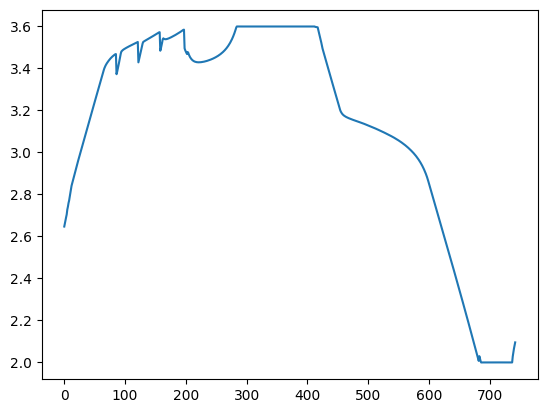

In [8]:
b9c0 = mit_bat_dict['b9c0']['cycles']['0']['V']
plt.plot(b9c0)

In [9]:
b9c43 = mit_bat_dict['b9c43']
for key in b9c43['cycles'].keys():
    mit_current.append(b9c43['cycles'][key]['I'])
    mit_voltage.append(b9c43['cycles'][key]['V'])
mit_current = np.concatenate(mit_current, axis=0)
mit_voltage = np.concatenate(mit_voltage, axis=0)
print(len(mit_current), len(mit_voltage)) # 781367

781367 781367


In [10]:
tri_current = tri_current[tri_current > 0]
tri_voltage = tri_voltage[tri_voltage > 2.6]
mit_current= mit_current[mit_current > 0]
mit_voltage = mit_voltage[mit_voltage > 2.6]

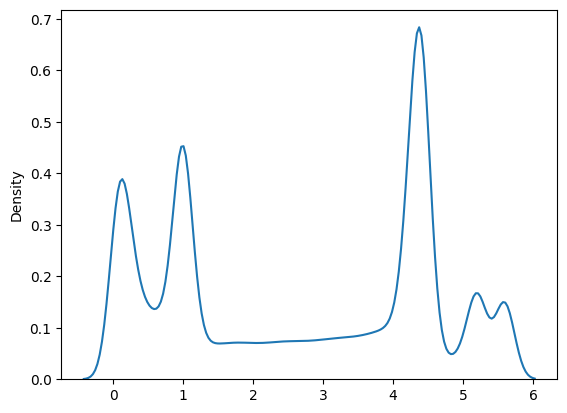

In [11]:
mit_current_artist = sns.kdeplot(mit_current)
mit_current_x, mit_current_y = mit_current_artist.lines[0].get_data()

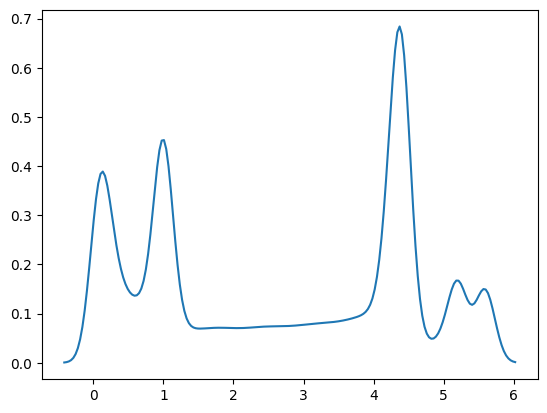

In [12]:
plt.plot(mit_current_x, mit_current_y)

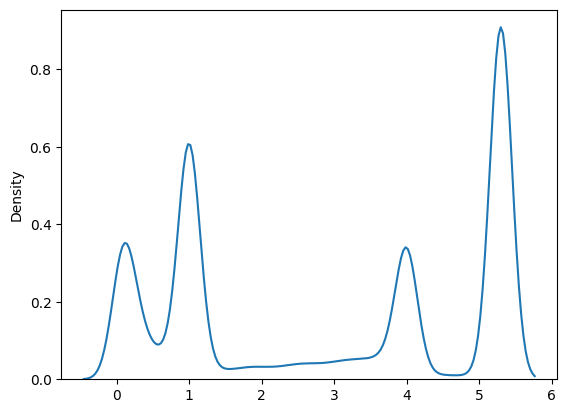

In [13]:
tri_current_artist = sns.kdeplot(tri_current)
tri_current_x, tri_current_y = tri_current_artist.lines[0].get_data()

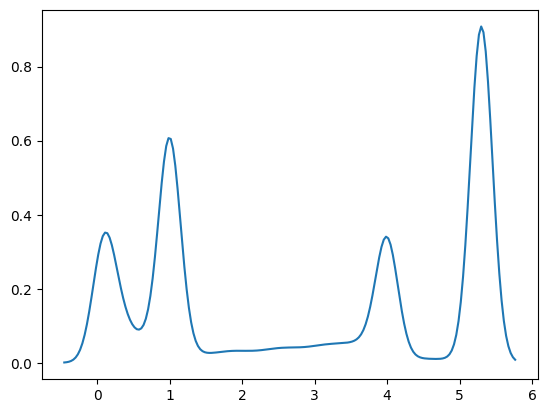

In [14]:
plt.plot(tri_current_x, tri_current_y)

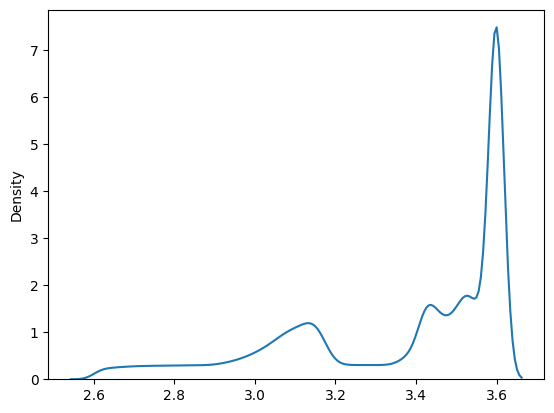

In [15]:
mit_voltage_artist = sns.kdeplot(mit_voltage)
mit_voltage_x, mit_voltage_y = mit_voltage_artist.lines[0].get_data()

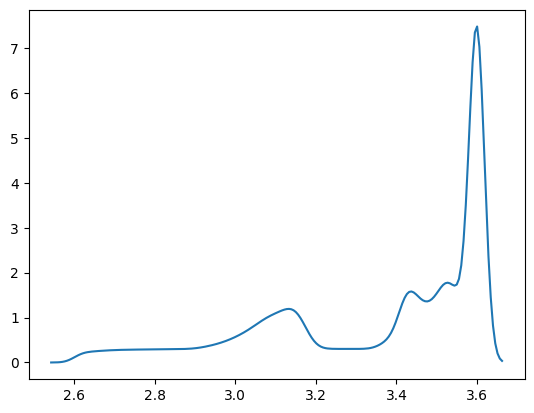

In [16]:
plt.plot(mit_voltage_x, mit_voltage_y)

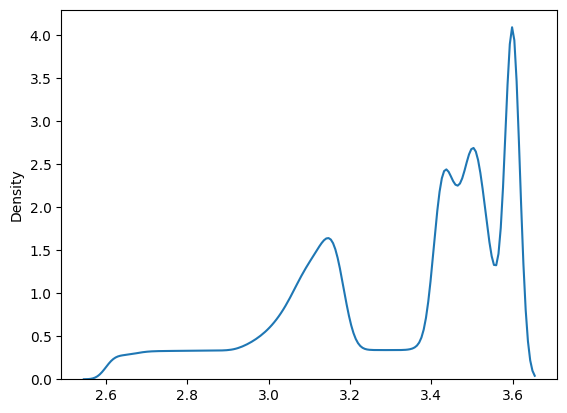

In [17]:
tri_voltage_artist = sns.kdeplot(tri_voltage)
tri_voltage_x, tri_voltage_y = tri_voltage_artist.lines[0].get_data()

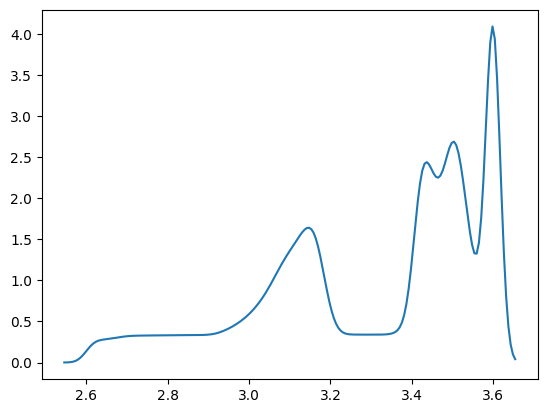

In [18]:
plt.plot(tri_voltage_x, tri_voltage_y)

200 200 200 200


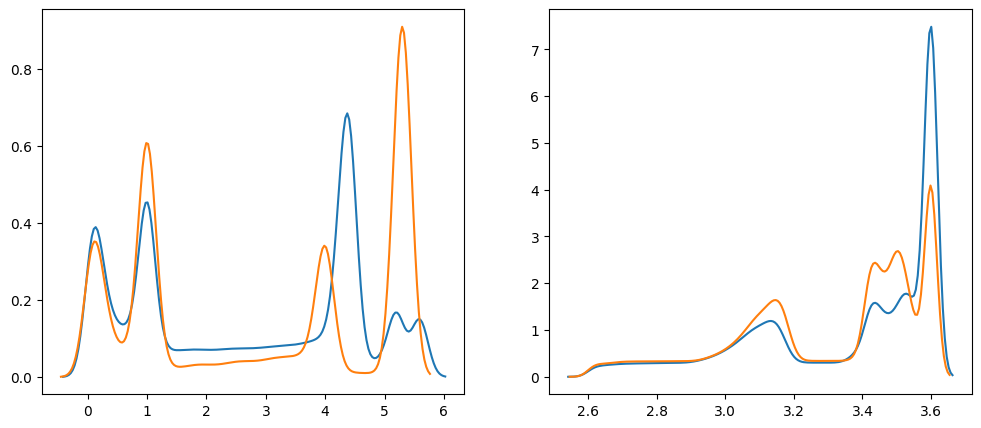

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(mit_current_x, mit_current_y)
ax[0].plot(tri_current_x, tri_current_y)
ax[1].plot(mit_voltage_x, mit_voltage_y)
ax[1].plot(tri_voltage_x, tri_voltage_y)

print(len(mit_current_x), len(mit_voltage_x), len(tri_current_x), len(tri_voltage_x))

# save to excel
col1, col2 = 'value', 'density'
mit_current_kde = pd.DataFrame({col1: mit_current_x, col2: mit_current_y})
mit_voltage_kde = pd.DataFrame({col1: mit_voltage_x, col2: mit_voltage_y})
tri_current_kde = pd.DataFrame({col1: tri_current_x, col2: tri_current_y})
tri_voltage_kde = pd.DataFrame({col1: tri_voltage_x, col2: tri_voltage_y})
to_save = pd.concat([mit_current_kde, mit_voltage_kde, tri_current_kde, tri_voltage_kde], axis=1)

# writer = pd.ExcelWriter('mit_tri_kde.xlsx')
to_save.to_excel('mit_tri_kde.xlsx')